In [9]:
import numpy as np
import matplotlib.pyplot as plt

I think that as the step size increases, both the global and local error will increase as the Euler method uses linear approximations which are most effective when the step sizes are really small so that it can adjust to a new point at smaller intervals. I predict that approximations with large stepsizes will be very jagged. 

In [10]:
def exact_solution(x):
    exact = np.exp(-2 * x)
    return exact

In [11]:

def global_error(x,y):
    g_e = np.abs(exact_solution(x) - y)
    return g_e

def local_error(x_values):
    errors = []
    
    for i in range(len(x_values) - 1):
        h = x_values[i+1] - x_values[i]
        
        exact_step = exact_solution(x_values[i]) + h * f(x_values[i], exact_solution(x_values[i]))
        true_next = exact_solution(x_values[i+1])
        
        errors.append(np.abs(true_next - exact_step))
    
    return np.array(errors)


 h = 0.1
 Global error is [0.00000000e+00 1.87307531e-02 3.03200460e-02 3.68116361e-02
 3.97289641e-02 4.01994412e-02 3.90502119e-02 3.68817639e-02
 3.41243580e-02 3.10811602e-02 2.79611008e-02 2.49038124e-02
 2.19984766e-02 1.92979968e-02 1.68295975e-02 1.46026963e-02
 1.26147063e-02 1.08552718e-02 9.30932394e-03 7.95925305e-03
 6.78642384e-03 5.77220478e-03 4.89864227e-03 4.14887764e-03
 3.50738057e-03 2.96005381e-03 2.49424987e-03 2.09872930e-03
 1.76358241e-03 1.48012970e-03 1.24081214e-03 1.03907860e-03
 8.69275648e-04 7.26542737e-04 6.06714908e-04 5.06233773e-04
 4.22067255e-04 3.51637918e-04 2.92759559e-04 2.43581480e-04
 2.02539828e-04 1.68315330e-04 1.39796732e-04 1.16049320e-04
 9.62878964e-05 7.98536611e-05 6.61944875e-05 5.48481341e-05
 4.54279913e-05 3.76110033e-05 3.11274528e-05 2.57523371e-05
 2.12980978e-05 1.76085015e-05 1.45534969e-05 1.20248956e-05
 9.93275187e-06 8.20232949e-06 6.77156345e-06 5.58893849e-06
 4.61171681e-06 3.80445917e-06 3.13779156e-06 2.58737752e-

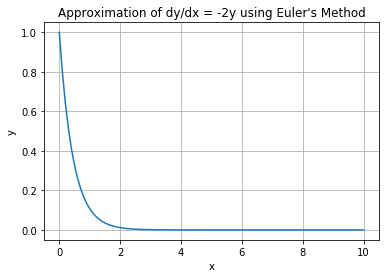

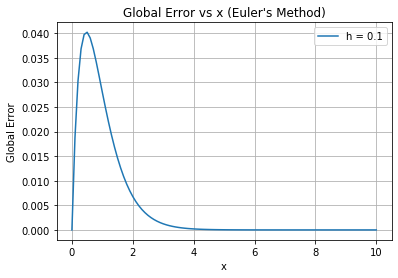

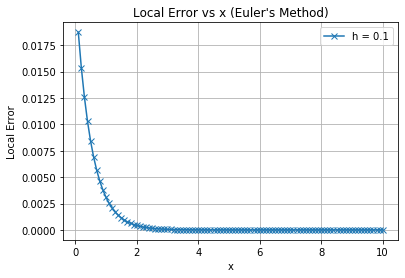


 h = 0.5
 Global error is [0.00000000e+00 3.67879441e-01 1.35335283e-01 4.97870684e-02
 1.83156389e-02 6.73794700e-03 2.47875218e-03 9.11881966e-04
 3.35462628e-04 1.23409804e-04 4.53999298e-05 1.67017008e-05
 6.14421235e-06 2.26032941e-06 8.31528719e-07 3.05902321e-07
 1.12535175e-07 4.13993772e-08 1.52299797e-08 5.60279644e-09
 2.06115362e-09]
 Local error is [3.67879441e-01 1.35335283e-01 4.97870684e-02 1.83156389e-02
 6.73794700e-03 2.47875218e-03 9.11881966e-04 3.35462628e-04
 1.23409804e-04 4.53999298e-05 1.67017008e-05 6.14421235e-06
 2.26032941e-06 8.31528719e-07 3.05902321e-07 1.12535175e-07
 4.13993772e-08 1.52299797e-08 5.60279644e-09 2.06115362e-09]


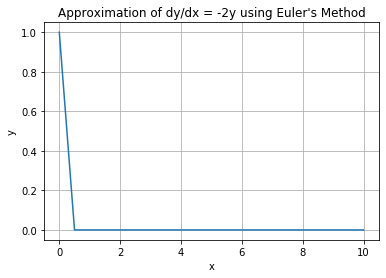

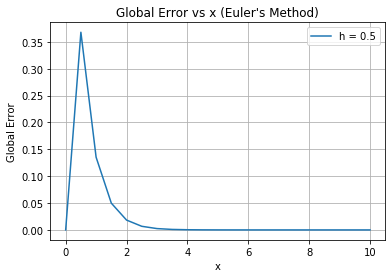

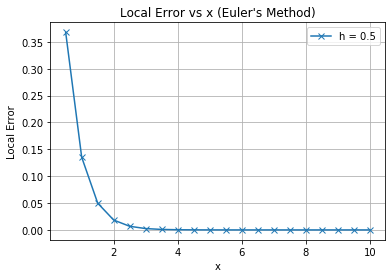


 h = 1.0
 Global error is [0.         1.13533528 0.98168436 1.00247875 0.99966454 1.0000454
 0.99999386 1.00000083 0.99999989 1.00000002 1.        ]
 Local error is [1.13533528e+00 1.53650922e-01 2.07943911e-02 2.81421480e-03
 3.80862558e-04 5.15441421e-05 6.97574107e-06 9.44063894e-07
 1.27765154e-07 1.72911334e-08]


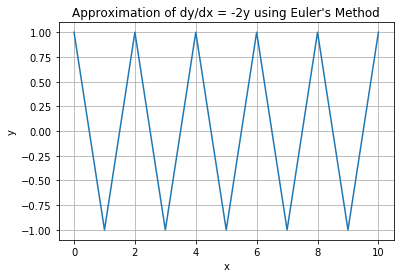

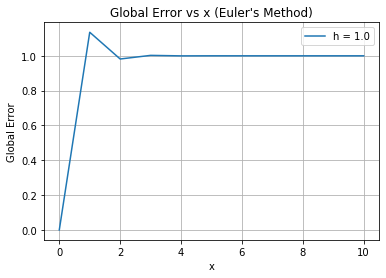

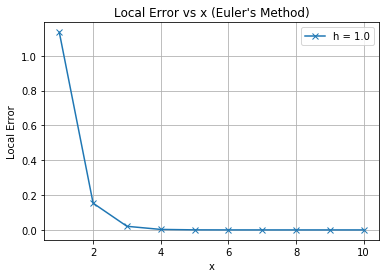


 h = 1.5
 Global error is [ 0.          2.03567399  3.99872737  8.0000454  15.99999838 32.00000006
 64.        ]
 Local error is [2.36900733e+00 8.45119516e-02 3.01487880e-03 1.07552766e-04
 3.83683667e-06 1.36875286e-07]


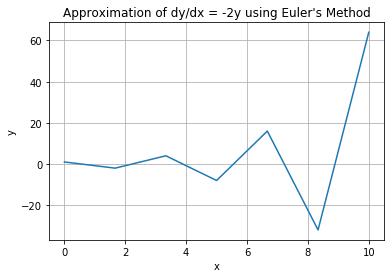

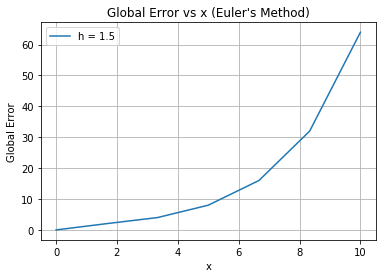

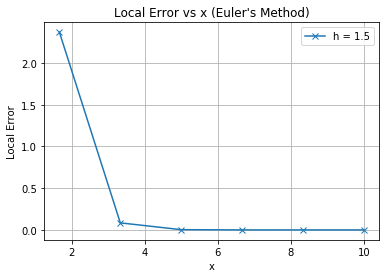

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
    return -2 * y


h_arr_2 = np.array([0.1,0.5,1.0,1.5])

for h in h_arr_2:
    x_start, x_end = 0,10
    num_steps = int((x_end - x_start) / h)

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)


    # Initial condition
    y_values[0] = 1  # y(0) = 1


    # Implement Euler's method

    for i in range(num_steps):

        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    #errors
    glob_error = global_error(x_values, y_values)
    loc_error = local_error(x_values)
    print(f"\n h = {h}")
    print(f" Global error is {glob_error}")
    print(f" Local error is {loc_error}")
    
    plt.plot(x_values, y_values, label="Euler's Method Approximation")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("Approximation of dy/dx = -2y using Euler's Method")
    plt.grid(True)
    plt.show()
    
      # Global error plot
    plt.plot(x_values, glob_error, label=f"h = {h}")
    plt.xlabel("x")
    plt.ylabel("Global Error")
    plt.title("Global Error vs x (Euler's Method)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Local error plot
    plt.plot(x_values[1:], loc_error, marker='x', label=f"h = {h}")
    plt.xlabel("x")
    plt.ylabel("Local Error")
    plt.title("Local Error vs x (Euler's Method)")
    plt.legend()
    plt.grid(True)
    plt.show()





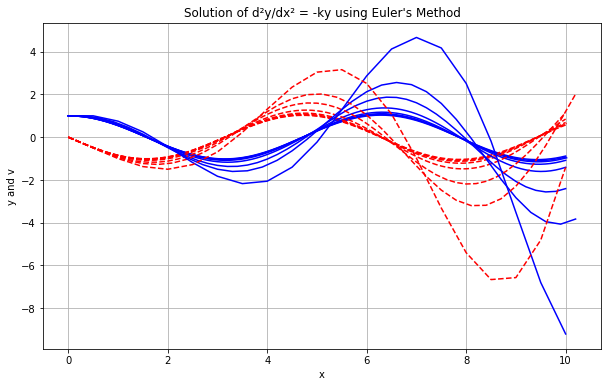

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters

k = 1.0        # Constant in the equation (e.g., spring constant)
h_arr = [.01, .02, .03,.05, .1, .2, .3, .5]       # Step size
x_start = 0    # Start of the interval
x_end = 10     # End of the interval
y_0 = 1.0      # Initial condition for y
v_0 = 0.0      # Initial condition for dy/dx

plt.figure(figsize=(10, 6))

for h in h_arr:
    # Create arrays to store x, y, and v values

    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Set initial conditions

    y_values[0] = y_0
    v_values[0] = v_0



    # Euler's Method loop

    for i in range(1, len(x_values)):
        # Current values
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]    

        # Update equations
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)
    
    plt.plot(x_values, y_values, label='Position y(x)', color = "blue")
    plt.plot(x_values, v_values, label='Velocity v(x)', color = "red", linestyle='--')
    

plt.xlabel('x')
plt.ylabel('y and v')
plt.title('Solution of d²y/dx² = -ky using Euler\'s Method')
plt.grid(True)


#legend would have may too many labels to show so i decided against it. 
#All of the lines are essentially either the position or the velocity vs time



The solution does seem to become unstable towards the end of the interval as the oscillations start to lose control and one of the veloity lines seems to be headed down towards negative infinity. This isn't exactly realistic because true mass-spring system in a perfect world would just oscillate with a certain amplitude.

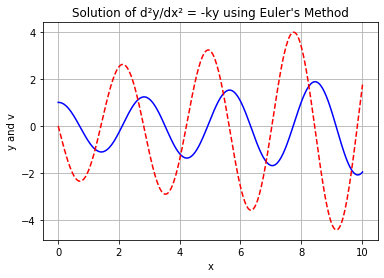

In [29]:
h_arr2 = [0.03]

k2 = 5

for h in h_arr2:
    # Create arrays to store x, y, and v values

    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Set initial conditions

    y_values[0] = y_0
    v_values[0] = v_0



    # Euler's Method loop

    for i in range(1, len(x_values)):
        # Current values
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]    

        # Update equations
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k2 * y_n)
    
    plt.plot(x_values, y_values, label='Position y(x)', color = "blue")
    plt.plot(x_values, v_values, label='Velocity v(x)', color = "red", linestyle='--')
    

plt.xlabel('x')
plt.ylabel('y and v')
plt.title('Solution of d²y/dx² = -ky using Euler\'s Method')
plt.grid(True)

The system oscillates at a faster frequencey with a higher value of k.

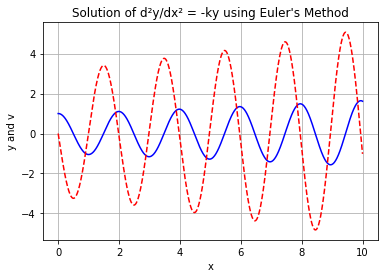

In [30]:
k3 = 10
h_arr3 = [.01]

for h in h_arr3:
    # Create arrays to store x, y, and v values

    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Set initial conditions

    y_values[0] = y_0
    v_values[0] = v_0



    # Euler's Method loop

    for i in range(1, len(x_values)):
        # Current values
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]    

        # Update equations
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k3 * y_n)
    
    plt.plot(x_values, y_values, label='Position y(x)', color = "blue")
    plt.plot(x_values, v_values, label='Velocity v(x)', color = "red", linestyle='--')
    

plt.xlabel('x')
plt.ylabel('y and v')
plt.title('Solution of d²y/dx² = -ky using Euler\'s Method')
plt.grid(True)

I don't think a higher value of h would help because the errors will just occur at a faster rate. The simulation would essentially fail and lose control.

